In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# data load
df = pd.read_csv("Data/netflix_titles.csv")

# display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# check shape of dataset (rows and columns)
print("Shape:", df.shape)

# check column names and data types
df.info()

# check missing values in each column
df.isnull().sum()

Shape: (8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
# fill missing values in categorical columns with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# drop rows where date_added or rating or duration is missing (very few rows)
df = df.dropna(subset=['date_added', 'rating', 'duration'])

# check missing values again to confirm
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [5]:
# check number of duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# remove duplicate rows if any
df = df.drop_duplicates()

# check shape after removing duplicates
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (8790, 12)


In [6]:
# convert date_added column to datetime format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# create new column for year added
df['year_added'] = df['date_added'].dt.year

# create new column for month added
df['month_added'] = df['date_added'].dt.month

# display updated dataframe
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


In [7]:
# summary statistics for numeric columns
df.describe()

,date_added,release_year,year_added,month_added
count,8790,8790.000000,8790.000000,8790.000000
mean,2019-05-17 21:44:01.638225,2014.183163,2018.873606,6.655859
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,4.000000
50%,2019-07-03 00:00:00,2017.000000,2019.000000,7.000000
75%,2020-08-19 18:00:00,2019.000000,2020.000000,10.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000
std,NaN,8.825466,1.573568,3.436103


In [8]:
# count of Movies vs TV Shows
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

C:\Users\Bushra Shahid\AppData\Local\Temp\ipykernel_4720\229531601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


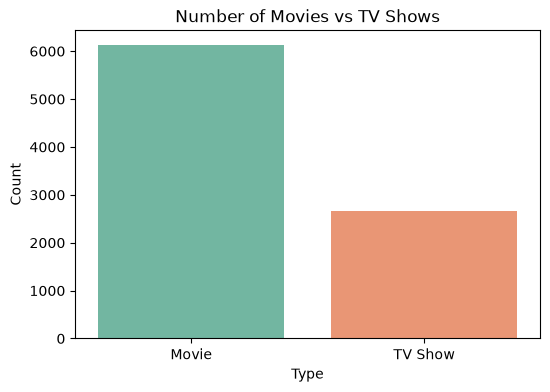

In [9]:
# visualize count of movies vs tv shows
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Number of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

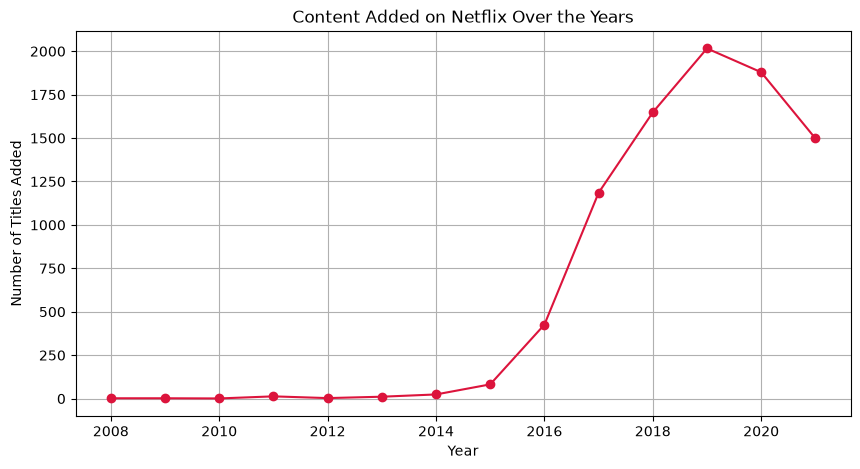

In [10]:
# count number of titles added each year
yearly_content = df['year_added'].value_counts().sort_index()

# plot trend of content added over years
plt.figure(figsize=(10,5))
plt.plot(yearly_content.index, yearly_content.values, marker='o', color='crimson')
plt.title('Content Added on Netflix Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.show()

C:\Users\Bushra Shahid\AppData\Local\Temp\ipykernel_4720\2786881932.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


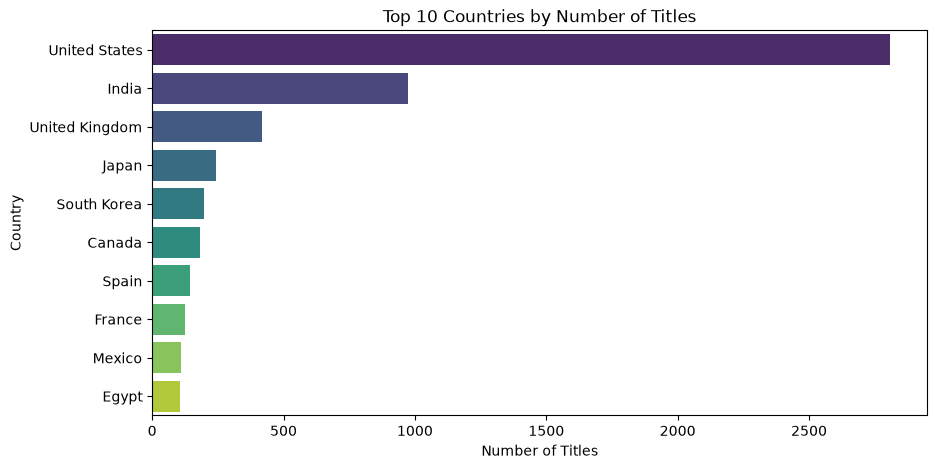

In [11]:
# get top 10 countries with most content (excluding 'Unknown')
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

# plot top 10 countries
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

C:\Users\Bushra Shahid\AppData\Local\Temp\ipykernel_4720\1462606356.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')


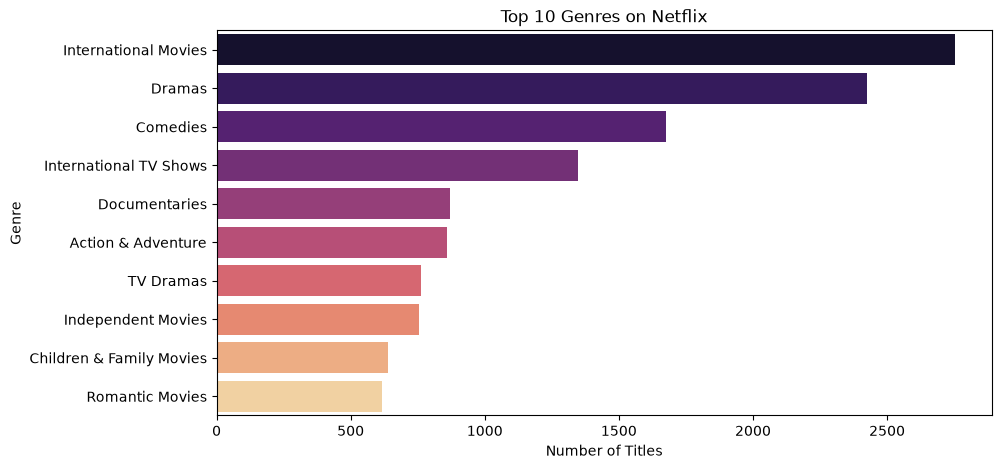

In [12]:
# split listed_in column since it has multiple genres separated by commas
genres = df['listed_in'].str.split(', ').explode()

# get top 10 genres
top_genres = genres.value_counts().head(10)

# plot top 10 genres
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

C:\Users\Bushra Shahid\AppData\Local\Temp\ipykernel_4720\1451987502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_count.index, y=rating_count.values, palette='coolwarm')


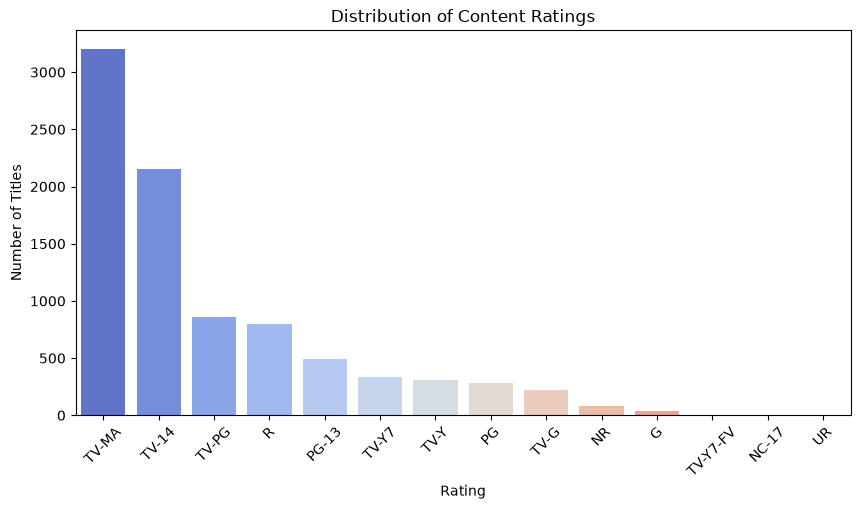

In [13]:
# count of each content rating
rating_count = df['rating'].value_counts()

# plot distribution of ratings
plt.figure(figsize=(10,5))
sns.barplot(x=rating_count.index, y=rating_count.values, palette='coolwarm')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

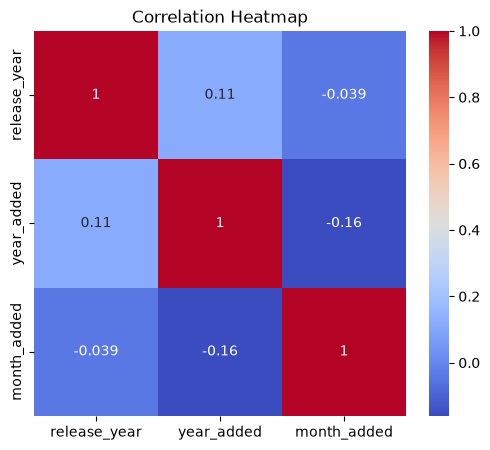

In [14]:
# select numeric columns for correlation
numeric_df = df[['release_year', 'year_added', 'month_added']]

# calculate correlation matrix
correlation = numeric_df.corr()

# plot heatmap of correlation
plt.figure(figsize=(6,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

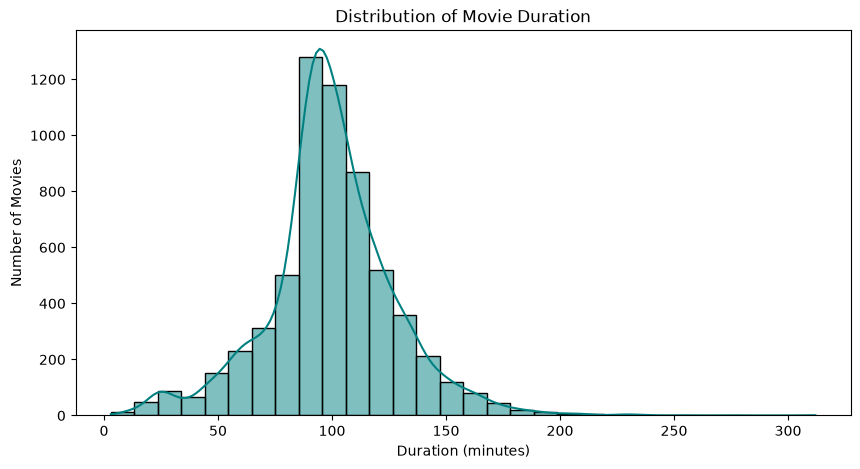

In [15]:
# extract only movies and convert duration to numeric (removing 'min')
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# plot histogram of movie durations
plt.figure(figsize=(10,5))
sns.histplot(movies_df['duration_min'], bins=30, color='teal', kde=True)
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

# Netflix Dataset - Exploratory Data Analysis (EDA)

**Objective:** Identify trends and patterns in Netflix content using summary statistics, correlation analysis, and visualizations.

## Data Cleaning
Missing values were found in `director`, `cast`, `country`, `date_added`, `rating`, and `duration` columns. Filled `director`, `cast`, and `country` with 'Unknown', and dropped the few rows missing `date_added`, `rating`, or `duration`. No duplicate rows were found. Final cleaned shape: (8790, 12).

## Feature Engineering
Converted `date_added` to datetime format and extracted `year_added` and `month_added` for trend analysis.

## Key Insights

**1. Movies vs TV Shows:** Netflix's catalog is dominated by movies, making up roughly 70% of all titles (6126 Movies) compared to 30% TV shows (2664 TV Shows).

**2. Content Growth Over the Years:** Content additions were minimal before 2015 but grew rapidly between 2016 and 2019, peaking around 2019. The slight drop in 2020-2021 could be due to production delays or incomplete data for the latest year.

**3. Top Content-Producing Countries:** The **United States** produces the most content by far, followed by **India** and the **United Kingdom**, reflecting Netflix's strong presence in these markets.

**4. Popular Genres:** **International Movies**, **Dramas**, and **Comedies** are the most common genres, showing Netflix's focus on diverse, globally appealing content.

**5. Content Ratings:** Most content is rated **TV-MA** and **TV-14**, indicating Netflix's catalog is primarily aimed at mature and teen audiences rather than young children.

**6. Correlation Analysis:** There is little to no strong correlation between `release_year`, `year_added`, and `month_added`, suggesting these variables don't have significant linear relationships in this dataset.

**7. Movie Duration:** Most movies fall between **90 and 120 minutes**, which aligns with standard feature film length.

## Conclusion
This EDA reveals that Netflix's catalog is movie-heavy, has grown significantly since 2016, is led by content from the US and India, favors mature-audience ratings, and mostly features standard-length movies and international/drama genres.